In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(r"C:\Users\tjyot\Downloads\archive1\IMDb Movies India.csv", encoding='ISO-8859-1')

df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [8]:
df.describe(include='all')

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
count,15509,14981,7240,13632,7919.000000,7920,14984,13892,13125,12365
unique,13838,102,182,485,NaN,2034,5938,4718,4891,4820
top,Anjaam,(2019),120 min,Drama,NaN,8,Jayant Desai,Ashok Kumar,Rekha,Pran
freq,7,410,240,2780,NaN,227,58,158,83,91
mean,NaN,NaN,NaN,NaN,5.841621,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.381777,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.100000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,4.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,6.800000,NaN,NaN,NaN,NaN,NaN


In [10]:
df.isna().sum()
df.duplicated().sum()

6

In [12]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5659 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      5659 non-null   object 
 1   Year      5659 non-null   object 
 2   Duration  5659 non-null   object 
 3   Genre     5659 non-null   object 
 4   Rating    5659 non-null   float64
 5   Votes     5659 non-null   object 
 6   Director  5659 non-null   object 
 7   Actor 1   5659 non-null   object 
 8   Actor 2   5659 non-null   object 
 9   Actor 3   5659 non-null   object 
dtypes: float64(1), object(9)
memory usage: 486.3+ KB


In [14]:
# Convert columns to proper format
df['Year'] = df['Year'].astype(str).str.replace(r'\(|\)', '', regex=True).astype(int)
df['Duration'] = pd.to_numeric(df['Duration'].astype(str).str.replace(' min', ''))
df['Votes'] = pd.to_numeric(df['Votes'].astype(str).str.replace(',', ''))

df.dtypes

Name         object
Year          int32
Duration      int64
Genre        object
Rating      float64
Votes         int64
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object

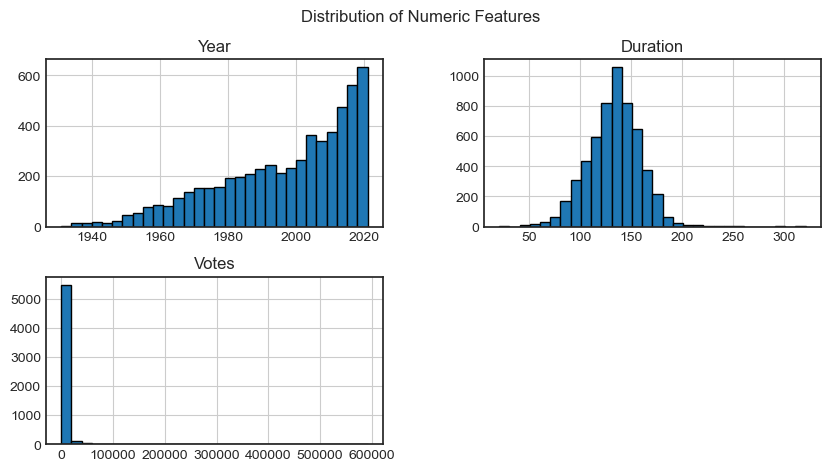

In [16]:
plt.style.use('seaborn-v0_8-white')

df[['Year', 'Duration', 'Votes']].hist(bins=30, edgecolor='black', figsize=(10,5))
plt.suptitle('Distribution of Numeric Features')
plt.show()

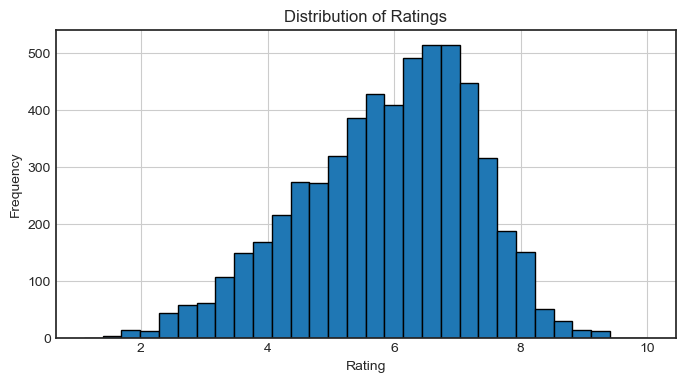

In [18]:
df['Rating'].hist(bins=30, edgecolor='black', figsize=(8,4))
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

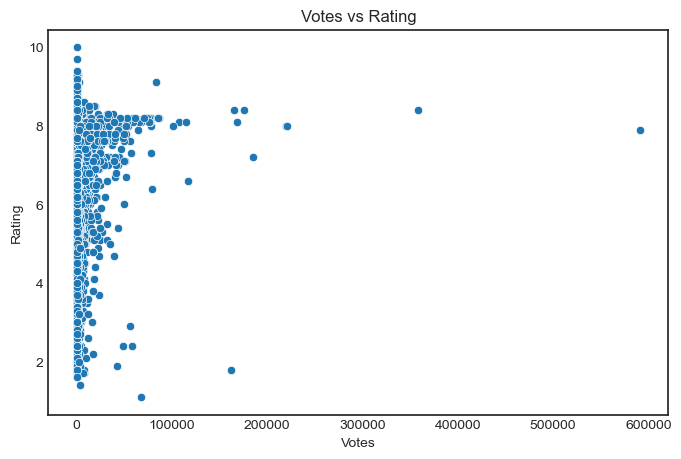

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Votes'], y=df['Rating'])
plt.title("Votes vs Rating")
plt.show()

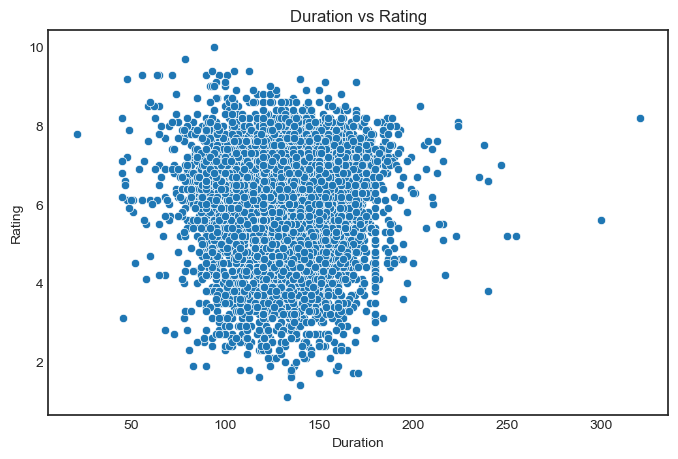

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Duration'], y=df['Rating'])
plt.title("Duration vs Rating")
plt.show()

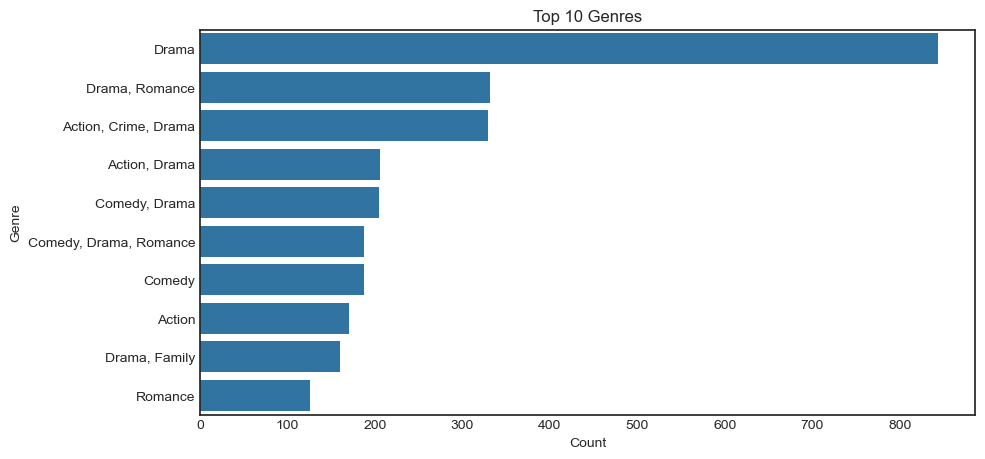

In [24]:
top_10_genres = df['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_10_genres.values, y=top_10_genres.index)
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

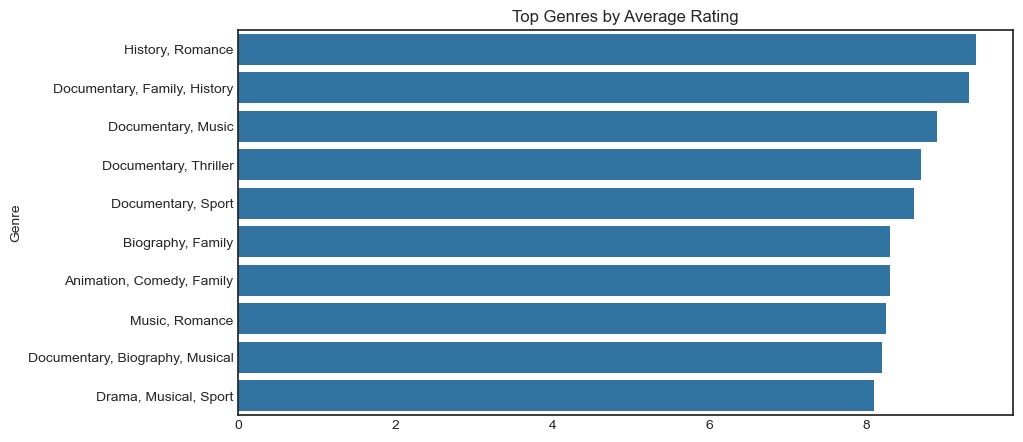

In [26]:
genre_rating = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=genre_rating.values, y=genre_rating.index)
plt.title("Top Genres by Average Rating")
plt.show()

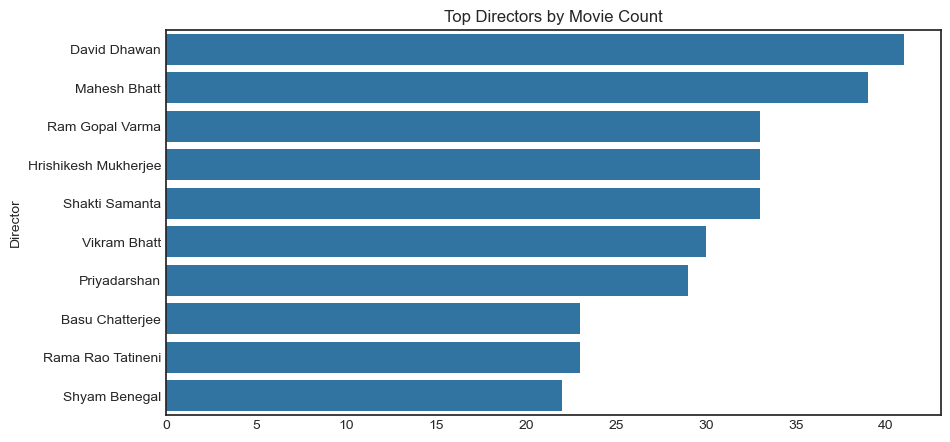

In [28]:
top_10_directors = df['Director'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_10_directors.values, y=top_10_directors.index)
plt.title("Top Directors by Movie Count")
plt.show()

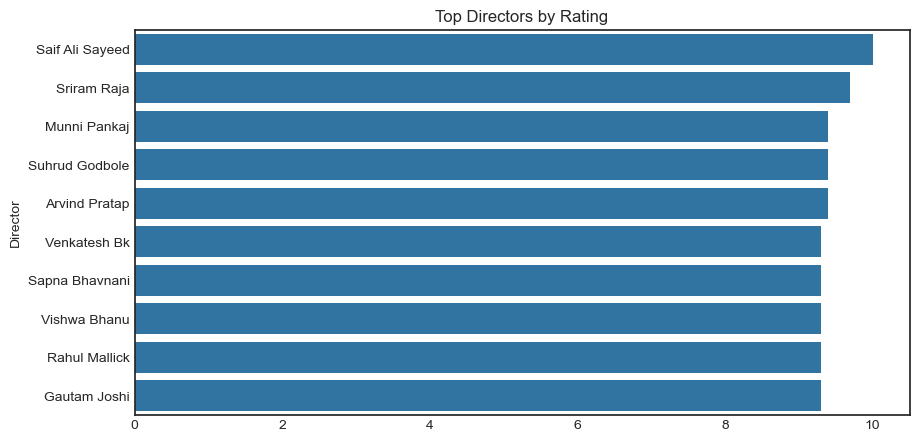

In [30]:
director_rating = df.groupby('Director')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=director_rating.values, y=director_rating.index)
plt.title("Top Directors by Rating")
plt.show()

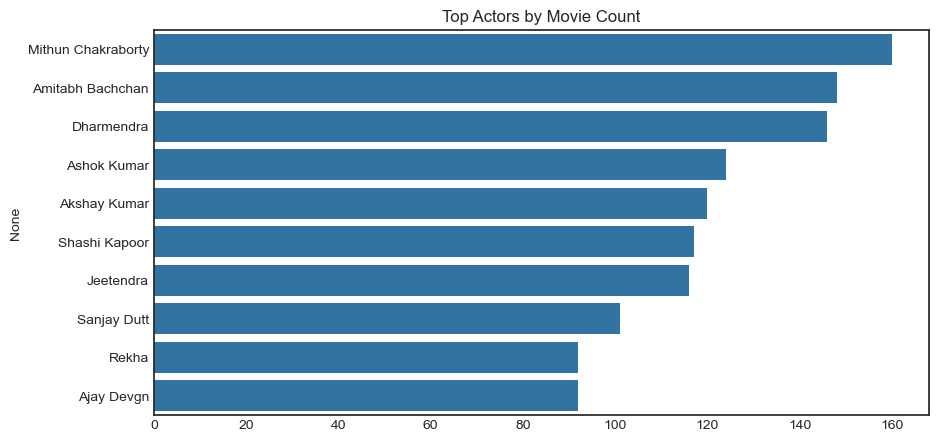

In [34]:
combined_actors = pd.concat([df['Actor 1'], df['Actor 2'], df['Actor 3']])
top_10_actors = combined_actors.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_10_actors.values, y=top_10_actors.index)
plt.title("Top Actors by Movie Count")
plt.show()

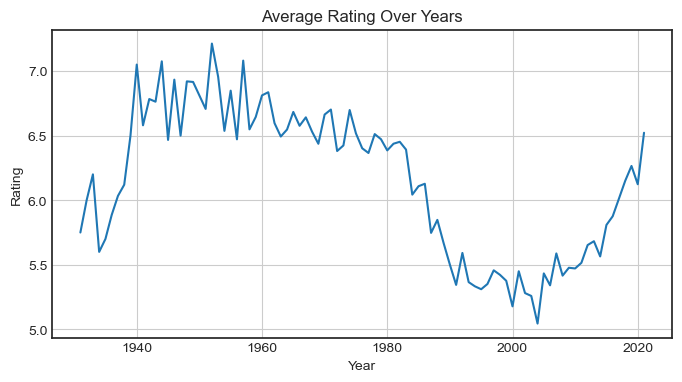

In [36]:
average_rating_per_year = df.groupby('Year')['Rating'].mean().reset_index()

plt.figure(figsize=(8,4))
plt.plot(average_rating_per_year['Year'], average_rating_per_year['Rating'])
plt.title("Average Rating Over Years")
plt.xlabel("Year")
plt.ylabel("Rating")
plt.grid(True)
plt.show()

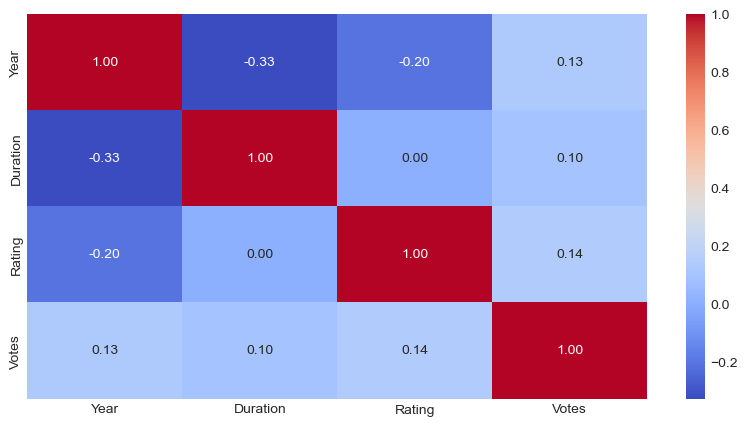

In [38]:
new_df = df.drop(columns=['Name','Actor 1','Actor 2','Actor 3','Director','Genre'])

corr = new_df.corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [40]:
df = df.drop('Name', axis=1)

df['Genre_Average_Rating'] = df.groupby('Genre')['Rating'].transform('mean')
df['Director_Average_Rating'] = df.groupby('Director')['Rating'].transform('mean')
df['Actor1_Average_Rating'] = df.groupby('Actor 1')['Rating'].transform('mean')
df['Actor2_Average_Rating'] = df.groupby('Actor 2')['Rating'].transform('mean')
df['Actor3_Average_Rating'] = df.groupby('Actor 3')['Rating'].transform('mean')

df.head()

,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Genre_Average_Rating,Director_Average_Rating,Actor1_Average_Rating,Actor2_Average_Rating,Actor3_Average_Rating
1,2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,6.415521,7.000000,6.850000,7.000000,7.000000
3,2019,110,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,5.716822,4.400000,5.420000,4.400000,4.450000
5,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,6.242222,5.313333,4.788889,5.786667,5.872727
6,2005,142,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,6.820000,7.383333,5.435000,6.933333,6.500000
8,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,5.477778,5.600000,5.600000,5.883333,5.600000


In [42]:
from sklearn.model_selection import train_test_split

x = df[['Year','Votes','Duration','Genre_Average_Rating','Director_Average_Rating',
        'Actor1_Average_Rating','Actor2_Average_Rating','Actor3_Average_Rating']]

y = df['Rating']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

In [46]:
from catboost import CatBoostRegressor

cb = CatBoostRegressor(verbose=0)
cb.fit(x_train, y_train)

y_pred_cb = cb.predict(x_test)

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Random Forest
MSE_rf = mean_squared_error(y_test, y_pred_rf)
MAE_rf = mean_absolute_error(y_test, y_pred_rf)
R2_rf = r2_score(y_test, y_pred_rf)

# CatBoost
MSE_cb = mean_squared_error(y_test, y_pred_cb)
MAE_cb = mean_absolute_error(y_test, y_pred_cb)
R2_cb = r2_score(y_test, y_pred_cb)

print("Random Forest R2:", R2_rf)
print("CatBoost R2:", R2_cb)

Random Forest R2: 0.8152567794573552
CatBoost R2: 0.8402739251533278


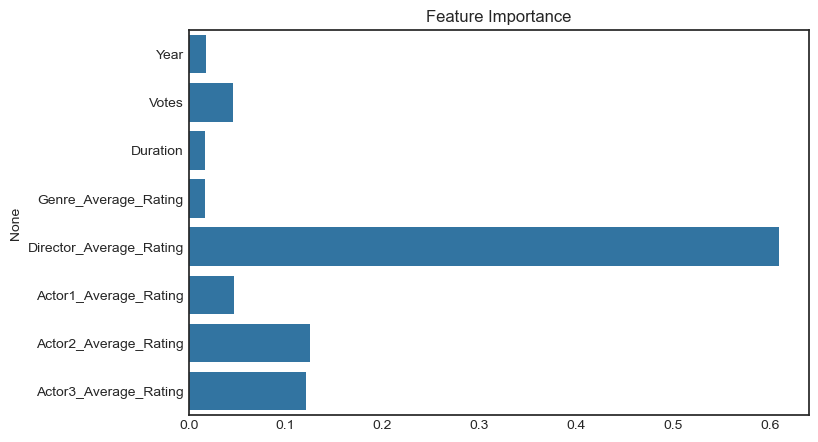

In [50]:
importances = rf.feature_importances_
features = x.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

In [52]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'CatBoost'],
    'R2 Score': [R2_rf, R2_cb],
    'MAE': [MAE_rf, MAE_cb]
})

results

,Model,R2 Score,MAE
0,Random Forest,0.815257,0.398664
1,CatBoost,0.840274,0.383821


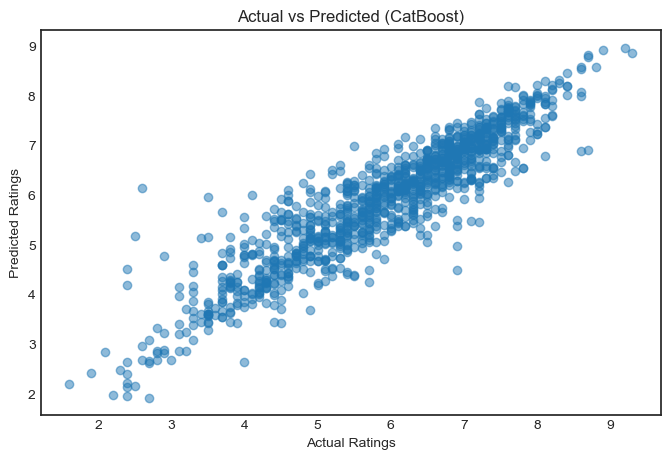

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_cb, alpha=0.5)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted (CatBoost)")
plt.show()

In [56]:
data = {
    'Year': [2018],
    'Votes': [100],
    'Duration': [130],
    'Genre_Average_Rating':[7.0],
    'Director_Average_Rating':[7.5],
    'Actor1_Average_Rating':[7.5],
    'Actor2_Average_Rating':[7.8],
    'Actor3_Average_Rating':[7.3]
}

trial_data = pd.DataFrame(data)

prediction = rf.predict(trial_data)
print("Predicted Rating:", prediction[0])

Predicted Rating: 7.624999999999996
